In [32]:
import psycopg2 #import package that enables a connectin with postgreSQL
import pandas as pd #import pandas for dataframe visualisation and potentially analysis
import matplotlib.pyplot as plt #import for visualisation purposes

def connect_db():
    connect = psycopg2.connect(
        host = "localhost",
        database = "DBM_Group 0",
        user = "postgres",
        password = "storm123"
)
    
    return connect

**Function 1 - Call content related characteristics and their respective box_office (Storm Wittebrood)**

This function hides the complexity of calling title, runtime, rating, release date, and worldwide box office from the SQL database.
These are most of the content related characteristics required for analysing the following sub-question:
*"To what extent are content characteristics of a movie associated with worldwide box-office performance?"*

In [33]:
def movie_bo (): #make it easy to call the overlapping movies in movie and box_office dataset
    connect = connect_db() #open the database connection defined above
    cur = connect.cursor() #create cursor to run SQL

#execute cursor function
#select title and runtime from movie
#rating from rating table joined by the matching rating ids between movie and rating table
#box office from box_office table joined by the matching urls between movie and box_office tables
    cur.execute(""" 
        select
            movie.title,
            movie.runtime,
            rating.rating_name,
            movie.release_date,
            box_office.worldwide_box_office
        from movie
        join rating
            on movie.rating_id = rating.rating_id
        join box_office
            on movie.url = box_office.movie_url;
    """)

    rows = cur.fetchall() #store all rows as rows

    columns = [
        "title",
        "runtime",
        "rating",
        "release_date",
        "worldwide_box_office"
    ] #define column names for dataframe

    df = pd.DataFrame(rows, columns=columns)

    cur.close()
    connect.close()

    return df

In [34]:
df = movie_bo()
df.head()

,title,runtime,rating,release_date,worldwide_box_office
0,10 Years,100.0,R,2012-09-14,987640.0
1,360,110.0,R,2012-08-03,4141251.0
2,44 Inch Chest,95.0,R,2010-01-15,NaN
3,Annapolis,108.0,PG-13,2006-01-27,17224992.0
4,"10,000 km",99.0,R,2015-07-10,20452.0


**Function 2 - Call genre and box_office relation (Storm Wittebrood)** 

The reason for creating two seperate functions for the content characterisitcs is relatively simple: Runtime and rating have a one-to-one relationship with a movie and will therefore result in one row per movie. Genre has a many-to-many relationship with movies, since one movie can have several genres. Therefore, including genre would have resulted in multiple rows per movie, making analysis more difficult. 

In [35]:
def genre_box_office (): #Function for calling the genre per movie and its corresponding box_office
    connect = connect_db() #open the database connection defined above
    cur = connect.cursor() #create cursor to run SQL

#execute cursor function
#select the movie title from movie
#select the genre name from genre
#select worldwide_box_office from box_office
#match movie records with their box_office data using URL
#join the junction table between movie and genre
#join with genre on genre_id   

    cur.execute(""" 
        select
            movie.title, 
            movie.release_date,                       
            genre.genre_name,                   
            box_office.worldwide_box_office     
        from movie
        join box_office                         
            on movie.url = box_office.movie_url
        join movie_genre                        
            on movie.url = movie_genre.url
        join genre                               
            on movie_genre.genre_id = genre.genre_id;
    """)

    rows = cur.fetchall() #store all rows as rows

    columns = [
        "title",
        "release_date",
        "genre",
        "worldwide_box_office"
    ] #define column names for dataframe

    df = pd.DataFrame(rows, columns=columns)

    cur.close()
    connect.close()

    return df

In [36]:
df2 = genre_box_office()
df2.head()

,title,release_date,genre,worldwide_box_office
0,10 Years,2012-09-14,Drama,987640.0
1,10 Years,2012-09-14,Comedy,987640.0
2,10 Years,2012-09-14,Romance,987640.0
3,360,2012-08-03,Drama,4141251.0
4,360,2012-08-03,Romance,4141251.0


**Analysis 1 - Genre (Storm Wittebrood)**

In [37]:
#First, a quick statistical overview of the genres within the dataset is required to understand the data 
df_genre = genre_box_office() #use the encapsulator

genre_summary = ( 
    df_genre.groupby("genre")["worldwide_box_office"].agg(["count","mean","std"]).sort_values("count",ascending=False) #creating a table that takes the box_office per genre with the corresponding count, mean and std
)

genre_summary #show table

,count,mean,std
genre,,,
Drama,2737,5.073366e+07,1.148405e+08
Comedy,1686,9.392277e+07,1.700016e+08
Thriller,1542,9.495684e+07,1.772013e+08
Action,966,2.030630e+08,2.986322e+08
Romance,898,6.926084e+07,1.293259e+08
Adventure,764,2.728116e+08,3.475633e+08
Crime,740,7.544308e+07,1.511324e+08
Horror,555,5.895634e+07,9.889158e+07
Mystery,496,9.070857e+07,1.584942e+08


Some movies have very limited appearances, further analysis will only take genres with a box_office count >50

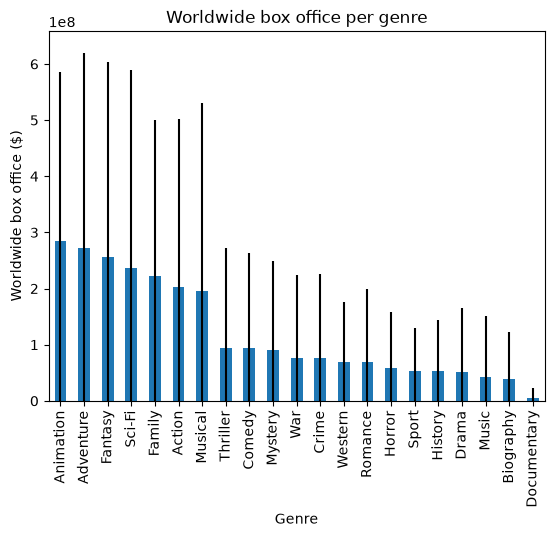

In [38]:
genre_summary = genre_summary[genre_summary["count"] > 50] #exclude genres with lower than 50 appearences

genre_summary = genre_summary.sort_values("mean", ascending = False) #sort by genres with highest average box_office

#Want to show average box_office and STDEV into one plot ussing the Y-error value
genre_summary["mean"].plot(     #create plot of genre_summary
    kind = "bar",               #bar plot
    yerr = genre_summary["std"] # y error value std                          
)

plt.title("Worldwide box office per genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Worldwide box office ($)")
plt.ylim(bottom=0) #dont want negative y error since it does not add value
plt.show()



The graph shows that Animation, Adventure, and Sci-Fi have the heighest average worldwide box office. However, the large standard deviations across most genres indicate a lot of variation of box office performance within the genres. Therefore, the figure suggest differences in average performances per genres, but it alone cannot consistently determine worldwide box office performance

**Analysis 2 - Runtime and Rating (Storm Wittebrood)**

For rating, exactly the same can be done as for genre

In [39]:
#First, a statistical overview of the ratings within the dataset is required to understand the data 
df_movie = movie_bo() #use the encapsulator

rating_summary = ( 
    df_movie.groupby("rating")["worldwide_box_office"].agg(["count","mean","std"]).sort_values("count",ascending=False) #creating a table that takes the box_office per rating with the corresponding count, mean and std
)

rating_summary #show table

,count,mean,std
rating,,,
R,1969,4.692818e+07,8.991059e+07
PG-13,1418,1.433250e+08,2.522988e+08
PG,538,1.690940e+08,2.447092e+08
G,74,1.743060e+08,2.399785e+08
TV-MA,61,1.274399e+07,2.624507e+07
NC-17,23,4.025805e+07,5.079852e+07
TV-14,16,5.498148e+07,9.926771e+07
TV-PG,9,5.181207e+07,1.003746e+08
TV-G,5,3.802173e+08,3.427727e+08


First insight is the TV classifications being on the list. The scope of this project is to focus on box_office performance and therefore about theatrical film ratings. 
The second insight is that some ratings have very limited appearances.
Therefore, , further analysis will only take **theatrical** film ratings with a box_office count >50: R, PG-13, PG, G

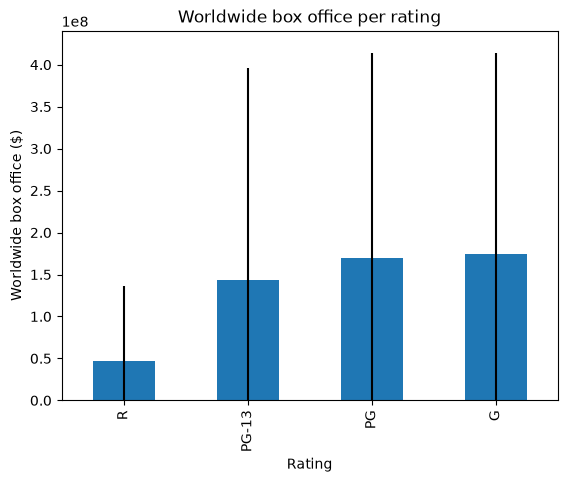

In [41]:
rating_summary = rating_summary[rating_summary["count"] > 61] #exclude all non theatrical film ratings and theatrical film ratings with count <50 

#Want to show average box_office and STDEV into one plot ussing the Y-error value
rating_summary["mean"].plot(     #create plot of genre_summary
    kind = "bar",               #bar plot
    yerr = rating_summary["std"] # y error value std                          
)

plt.title("Worldwide box office per rating")
plt.suptitle("")
plt.xlabel("Rating")
plt.ylabel("Worldwide box office ($)")
plt.ylim(bottom=0) #dont want negative y error since it does not add value
plt.show()

G and PG movies have the highest average worldwide box office, followed by PG-13, while R rating movies earn substantially less. Again, the large standard deviations indicate variation within each category. Therefore the graph suggest differences in average earnings, but the differences cannot be considered statistically based on this visualisation alone. 

In [ ]:
#understand the correlation of runtime on worldwide box_office
runtime_data = df_movie[["runtime","worldwide_box_office"]] #taking runtime and worldwide box office from the dataset
runtime_data.corr()

,runtime,worldwide_box_office
runtime,1.000000,0.320681
worldwide_box_office,0.320681,1.000000


Runtime has a weak to moderate postive linear relationship with worldwide box office perfromance (corr = 0.321)

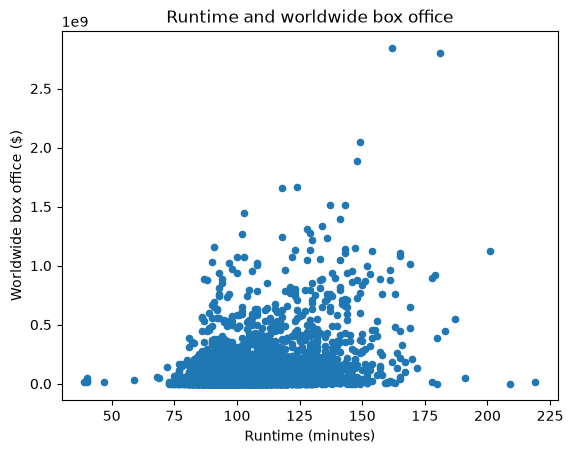

In [ ]:
#creating scatter plot
runtime_data.plot(
    kind="scatter",
    x="runtime",
    y="worldwide_box_office",
)

plt.title("Runtime and worldwide box office")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Worldwide box office ($)")
plt.show()

The scatterplot supports this relationship: Variation remains and no real conclusion can be drawn from these examples.